In [4]:
#!pip install "transformers==4.44.0"

In [5]:
!pip show tensorflow
!pip show transformers

Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /usr/local/lib/python3.12/dist-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: dopamine_rl, tensorflow-text, tf_keras, ydf_tf
Name: transformers
Version: 4.44.0
Summary: State-of-the-art Machine Learning for JAX, PyTorch and TensorFlow
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.12/dist-packages
Re

In [3]:
import pandas as pd
import tensorflow as tf
from transformers import BertTokenizer, TFBertForSequenceClassification
from sklearn.model_selection import train_test_split

# **FOLD 1 - GPT**

In [6]:
import json

with open("train_GPT.jsonl", "r", encoding="utf-8") as f:
    train_data = [json.loads(line) for line in f]

with open("test_GPT.jsonl", "r", encoding="utf-8") as f:
    test_data = [json.loads(line) for line in f]

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)


In [7]:
def label_map(label):
    if label == "AI":
        return 1
    else:
        return 0

train_df["label"] = train_df["label"].apply(label_map)
test_df["label"] = test_df["label"].apply(label_map)

train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()

val_texts = test_df["text"].tolist()
val_labels = test_df["label"].tolist()

print("Train label distribution:")
print(train_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())


Train label distribution:
label
0    2295
1    2040
Name: count, dtype: int64

Test label distribution:
label
1    1020
0     765
Name: count, dtype: int64


In [8]:
print("Train shape:", train_df.shape)
print(train_df.head())

print("Test shape:", test_df.shape)
print(test_df.head())

Train shape: (4335, 7)
                                                text  label AI_used  chunk_no  \
0  Din această pricină, calculul offline al tabel...      0    none         9   
1  (1970), Pentru o teorie a instruirii, EDP, abo...      0    none        17   
2  Acest fapt ne conduce la ipoteza că • produc m...      0    none         8   
3  Întâi, vom face o scurtă trecere prin fundamen...      0    none         1   
4  Apoi, abilitățile de comunicare ale unei echip...      0    none         4   

   source                                         source_url  \
0     128  https://rochi.utcluj.ro/rrioc/articole/RRIOC-2...   
1     144  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
2      20  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...   
3     158  https://rochi.utcluj.ro/rrioc/articole/RRIOC-6...   
4      61  https://rochi.utcluj.ro/rrioc/articole/RRIOC-2...   

   year_of_publication  
0                 2011  
1                 2012  
2                 2008  
3    

In [9]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("dumitrescustefan/bert-base-romanian-cased-v1")

max_length = 512

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length = max_length,
    return_tensors='tf'
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length = max_length,
    return_tensors='tf'
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/29.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [10]:
print("Num examples in encodings:", train_encodings["input_ids"].shape[0])
print("Num labels:", len(train_labels))

Num examples in encodings: 4335
Num labels: 4335


In [11]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_labels
))

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings),
    val_labels
))

In [12]:
import tensorflow as tf
from transformers import TFBertForSequenceClassification

model = TFBertForSequenceClassification.from_pretrained(
    'dumitrescustefan/bert-base-romanian-cased-v1',
    num_labels=2,
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
    run_eagerly=True
)

model.safetensors:   0%|          | 0.00/500M [00:00<?, ?B/s]

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [13]:
train_dataset = train_dataset.shuffle(100).batch(16)
val_dataset = val_dataset.batch(16)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)

Epoch 1/3


271/271 [==============================] - 275s 907ms/step - loss: 0.0684 - accuracy: 0.9737 - val_loss: 0.0474 - val_accuracy: 0.9854
Epoch 2/3
271/271 [==============================] - 223s 822ms/step - loss: 0.0212 - accuracy: 0.9928 - val_loss: 0.0472 - val_accuracy: 0.9826
Epoch 3/3
271/271 [==============================] - 221s 815ms/step - loss: 0.0030 - accuracy: 0.9988 - val_loss: 0.1565 - val_accuracy: 0.9513


In [14]:
loss, accuracy = model.evaluate(val_dataset)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

112/112 [==============================] - 24s 213ms/step - loss: 0.1565 - accuracy: 0.9513
Validation Loss: 0.15650959312915802
Validation Accuracy: 0.951260507106781


In [15]:
import numpy as np

y_true = []
y_pred = []

for batch_features, batch_labels in val_dataset:
    logits = model(batch_features, training=False).logits
    predictions = tf.math.argmax(logits, axis=1)

    y_pred.extend(predictions.numpy())
    y_true.extend(batch_labels.numpy())

              precision    recall  f1-score   support

       Human     0.8979    1.0000    0.9462       765
          AI     1.0000    0.9147    0.9555      1020

    accuracy                         0.9513      1785
   macro avg     0.9489    0.9574    0.9508      1785
weighted avg     0.9562    0.9513    0.9515      1785



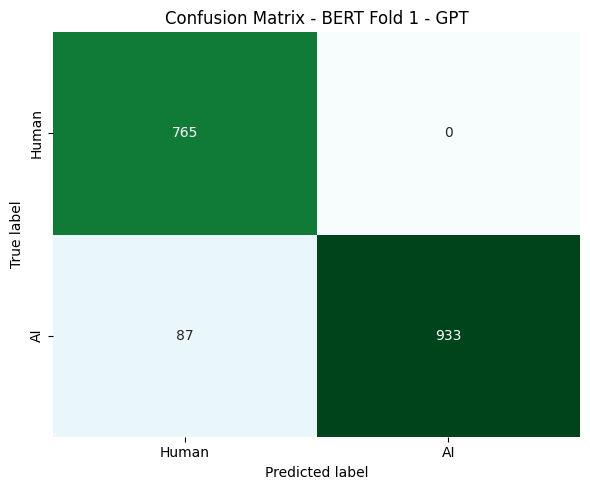

In [16]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

class_names = ["Human", "AI"]

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

conf_mat = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="BuGn",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - BERT Fold 1 - GPT")
plt.tight_layout()
plt.show()

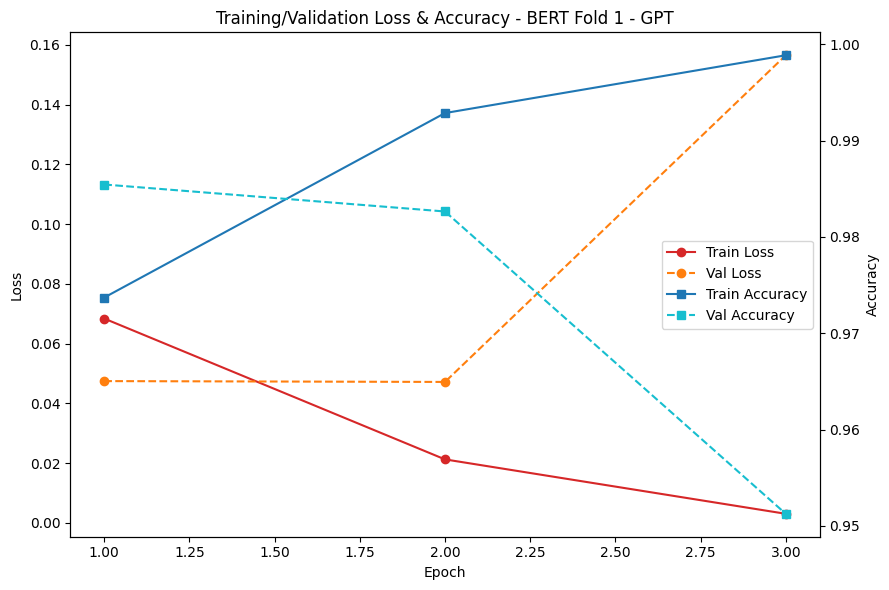

In [17]:
import matplotlib.pyplot as plt

hist = history.history
epochs_range = range(1, len(hist["loss"]) + 1)

fig, ax1 = plt.subplots(figsize=(9, 6))

#loss
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
line1 = ax1.plot(epochs_range, hist["loss"], color="tab:red", marker="o", label="Train Loss")
line2 = ax1.plot(epochs_range, hist["val_loss"], color="tab:orange", marker="o", linestyle="--", label="Val Loss")
ax1.tick_params(axis="y")

#accuracy
ax2 = ax1.twinx()
ax2.set_ylabel("Accuracy")
line3 = ax2.plot(epochs_range, hist["accuracy"], color="tab:blue", marker="s", label="Train Accuracy")
line4 = ax2.plot(epochs_range, hist["val_accuracy"], color="tab:cyan", marker="s", linestyle="--", label="Val Accuracy")
ax2.tick_params(axis="y")

#legend
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Training/Validation Loss & Accuracy - BERT Fold 1 - GPT")
fig.tight_layout()
plt.show()

In [18]:
examples = {
    ("correct", 0): [],
    ("correct", 1): [],
    ("incorrect", 0): [],
    ("incorrect", 1): [],
}

max_per_group = 3

for i in range(len(y_true)):
    true_label = y_true[i]
    pred_label = y_pred[i]
    is_correct = (true_label == pred_label)
    key = ("correct" if is_correct else "incorrect", true_label)

    if len(examples[key]) < max_per_group:
        examples[key].append(val_texts[i])

    if all(len(v) >= max_per_group for v in examples.values()):
        break

class_names = {0: "Human", 1: "AI"}

for (status, label), texts in examples.items():
    print(f"\n{'='*60}")
    print(f"{status.upper()} - class: {class_names[label]} ({len(texts)} examples)")
    print('='*60)
    for j, text in enumerate(texts, 1):
        print(f"\n[{j}] {text[:300]}{'...' if len(text) > 300 else ''}")


CORRECT - class: Human (3 examples)

[1] , respectiv G . 3 5 3 Analizând dinamica textuală a manualelor școlare analizate și folosind metodele descrise anterior, abordarea propusă a condus la următoarele concluzii: • Grupul de complexitate mediu al textului scade dacă verbele sunt eliminate complet; • Scăderea este treptată dacă verbele su...

[2] care participantul analizează subiectul, sub forma unei pauze de retragere a unor cuvinte, pauză intenționată sau planificată. Pe lângă pauzele din cadrul conversației putem preciza și cuvintele mai puțin importante, cele irelevante cum ar fi: abrevieri, simboluri. Aceste cuvinte pot să inducă parti...

[3] O pondere mai redusă a respondenților intervevați acum cinci ani declarau că se informează legat de viața de zi cu zi prin intermediul presei scrise (23%) sau a radioului (26%) și extrem de puțini declarau că folosesc pentru aceasta Internetul (6%). În același timp, datele atrăgeau atenția că în 200...

CORRECT - class: AI (3 examples)

[

In [19]:
#model download

model.save_pretrained("./bert-model_Fold1GPT")
tokenizer.save_pretrained("./bert-model_Fold1GPT")

from google.colab import files
import shutil
shutil.make_archive("Fold1GPT-bert-model", "zip", "./bert-model_Fold1GPT")
files.download("Fold1GPT-bert-model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **FOLD 2 - CLAUDE**

In [20]:
import json

with open("train_CLAUDE.jsonl", "r", encoding="utf-8") as f:
    train_data = [json.loads(line) for line in f]

with open("test_CLAUDE.jsonl", "r", encoding="utf-8") as f:
    test_data = [json.loads(line) for line in f]

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)


In [21]:
def label_map(label):
    if label == "AI":
        return 1
    else:
        return 0

train_df["label"] = train_df["label"].apply(label_map)
test_df["label"] = test_df["label"].apply(label_map)

train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()

val_texts = test_df["text"].tolist()
val_labels = test_df["label"].tolist()

print("Train label distribution:")
print(train_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())


Train label distribution:
label
0    2295
1    2040
Name: count, dtype: int64

Test label distribution:
label
1    1020
0     765
Name: count, dtype: int64


In [22]:
print("Train shape:", train_df.shape)
print(train_df.head())

print("Test shape:", test_df.shape)
print(test_df.head())

Train shape: (4335, 7)
                                                text  label  \
0  S-a dezvoltat o platformă pentru vizualizarea ...      1   
1  timp real. prin selecționarea datelor efective...      0   
2  Prin urmare, este esențial ca noile tehnologii...      1   
3  Analizând diversele aplicații mobile dedicate ...      1   
4  dacă distanța Levenshtein obținută este mai mi...      0   

                 AI_used  chunk_no  source  \
0            gpt-4-turbo         7     107   
1                   none        16      39   
2            gpt-4-turbo         8     127   
3  gemini-3.5-flash-lite         4     189   
4                   none         7      63   

                                          source_url  year_of_publication  
0  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...                 2011  
1  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...                 2009  
2  https://rochi.utcluj.ro/rrioc/articole/RRIOC-2...                 2011  
3  https://rochi.

In [23]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("dumitrescustefan/bert-base-romanian-cased-v1")

max_length = 512

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length = max_length,
    return_tensors='tf'
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length = max_length,
    return_tensors='tf'
)

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [24]:
print("Num examples in encodings:", train_encodings["input_ids"].shape[0])
print("Num labels:", len(train_labels))

Num examples in encodings: 4335
Num labels: 4335


In [25]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_labels
))

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings),
    val_labels
))

In [26]:
import tensorflow as tf
from transformers import TFBertForSequenceClassification

model = TFBertForSequenceClassification.from_pretrained(
    'dumitrescustefan/bert-base-romanian-cased-v1',
    num_labels=2,
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
    run_eagerly=True
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [27]:
train_dataset = train_dataset.shuffle(100).batch(16)
val_dataset = val_dataset.batch(16)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)

Epoch 1/3
271/271 [==============================] - 269s 905ms/step - loss: 0.0776 - accuracy: 0.9751 - val_loss: 0.3755 - val_accuracy: 0.8734
Epoch 2/3
271/271 [==============================] - 228s 842ms/step - loss: 0.0198 - accuracy: 0.9942 - val_loss: 0.2134 - val_accuracy: 0.9322
Epoch 3/3
271/271 [==============================] - 223s 822ms/step - loss: 0.0053 - accuracy: 0.9979 - val_loss: 0.1082 - val_accuracy: 0.9664


In [28]:
loss, accuracy = model.evaluate(val_dataset)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

112/112 [==============================] - 24s 215ms/step - loss: 0.1082 - accuracy: 0.9664
Validation Loss: 0.10819468647241592
Validation Accuracy: 0.9663865566253662


In [29]:
import numpy as np

y_true = []
y_pred = []

for batch_features, batch_labels in val_dataset:
    logits = model(batch_features, training=False).logits
    predictions = tf.math.argmax(logits, axis=1)

    y_pred.extend(predictions.numpy())
    y_true.extend(batch_labels.numpy())

              precision    recall  f1-score   support

       Human     0.9770    0.9438    0.9601       765
          AI     0.9589    0.9833    0.9710      1020

    accuracy                         0.9664      1785
   macro avg     0.9679    0.9636    0.9655      1785
weighted avg     0.9667    0.9664    0.9663      1785



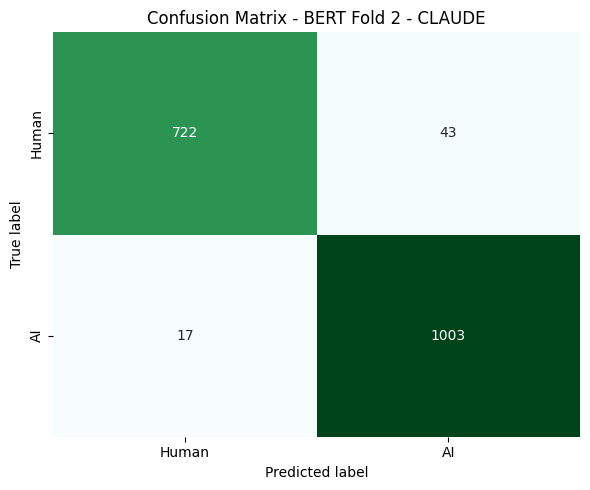

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

class_names = ["Human", "AI"]

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

conf_mat = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="BuGn",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - BERT Fold 2 - CLAUDE")
plt.tight_layout()
plt.show()

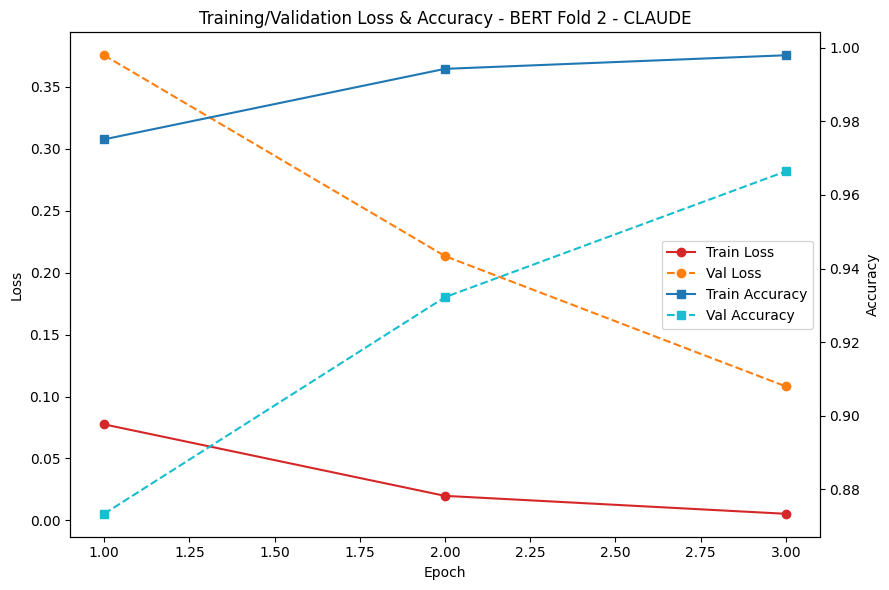

In [31]:
import matplotlib.pyplot as plt

hist = history.history
epochs_range = range(1, len(hist["loss"]) + 1)

fig, ax1 = plt.subplots(figsize=(9, 6))

#loss
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
line1 = ax1.plot(epochs_range, hist["loss"], color="tab:red", marker="o", label="Train Loss")
line2 = ax1.plot(epochs_range, hist["val_loss"], color="tab:orange", marker="o", linestyle="--", label="Val Loss")
ax1.tick_params(axis="y")

#accuracy
ax2 = ax1.twinx()
ax2.set_ylabel("Accuracy")
line3 = ax2.plot(epochs_range, hist["accuracy"], color="tab:blue", marker="s", label="Train Accuracy")
line4 = ax2.plot(epochs_range, hist["val_accuracy"], color="tab:cyan", marker="s", linestyle="--", label="Val Accuracy")
ax2.tick_params(axis="y")

#legend
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Training/Validation Loss & Accuracy - BERT Fold 2 - CLAUDE")
fig.tight_layout()
plt.show()

In [32]:
examples = {
    ("correct", 0): [],
    ("correct", 1): [],
    ("incorrect", 0): [],
    ("incorrect", 1): [],
}

max_per_group = 3

for i in range(len(y_true)):
    true_label = y_true[i]
    pred_label = y_pred[i]
    is_correct = (true_label == pred_label)
    key = ("correct" if is_correct else "incorrect", true_label)

    if len(examples[key]) < max_per_group:
        examples[key].append(val_texts[i])

    if all(len(v) >= max_per_group for v in examples.values()):
        break

class_names = {0: "Human", 1: "AI"}

for (status, label), texts in examples.items():
    print(f"\n{'='*60}")
    print(f"{status.upper()} - class: {class_names[label]} ({len(texts)} examples)")
    print('='*60)
    for j, text in enumerate(texts, 1):
        print(f"\n[{j}] {text[:300]}{'...' if len(text) > 300 else ''}")


CORRECT - class: Human (3 examples)

[1] • obiectele de învățare - suport al conceptelor. Obiectele de învățare (learning object) sunt văzute de standardele IMS ca resurse reproductibile și adresabile, digitale sau non-digitale, utilizate pentru a realiza activități de învățare sau activități suport. Cu ajutorul acestora se poate personali...

[2] A doua mare provocare o constituie optimizarea costurilor atașate dezvoltǎrii unor sisteme de procesare a limbajului, costuri, de multe ori, mari. În ultimii 7 ani, echipele de cercetare multidisciplinare s-au focalizat pe crearea de resurse lingvistice scrise și acustice, pe portarea tehnologiilor,...

[3] Discriminarea limbilor pe baza n-gramelor pleacă de la observația că pentru fiecare limbă anumite n-grame apar mai frecvent decât altele. Studii experimentale realizate de Cavnar and Trenkle (1994) au arătat că utilizarea trigramelor conduce la cele mai bune rezultate. Identificarea limbii se face 1...

CORRECT - class: AI (3 examples)

[

In [33]:
#model download

model.save_pretrained("./bert-model_Fold2CLAUDE")
tokenizer.save_pretrained("./bert-model_Fold2CLAUDE")

from google.colab import files
import shutil
shutil.make_archive("Fold2CLAUDE-bert-model", "zip", "./bert-model_Fold2CLAUDE")
files.download("Fold2CLAUDE-bert-model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **FOLD 3 - GEMINI**

In [34]:
import json

with open("train_GEMINI.jsonl", "r", encoding="utf-8") as f:
    train_data = [json.loads(line) for line in f]

with open("test_GEMINI.jsonl", "r", encoding="utf-8") as f:
    test_data = [json.loads(line) for line in f]

train_df = pd.DataFrame(train_data)
test_df = pd.DataFrame(test_data)


In [35]:
def label_map(label):
    if label == "AI":
        return 1
    else:
        return 0

train_df["label"] = train_df["label"].apply(label_map)
test_df["label"] = test_df["label"].apply(label_map)

train_texts = train_df["text"].tolist()
train_labels = train_df["label"].tolist()

val_texts = test_df["text"].tolist()
val_labels = test_df["label"].tolist()

print("Train label distribution:")
print(train_df["label"].value_counts())
print("\nTest label distribution:")
print(test_df["label"].value_counts())


Train label distribution:
label
0    2295
1    2040
Name: count, dtype: int64

Test label distribution:
label
1    1020
0     765
Name: count, dtype: int64


In [36]:
print("Train shape:", train_df.shape)
print(train_df.head())

print("Test shape:", test_df.shape)
print(test_df.head())

Train shape: (4335, 7)
                                                text  label  \
0  Tehnologiile Asistive (TA) au revoluționat mod...      1   
1  Testele au fost realizate pentru obținerea div...      0   
2  Activitatea în condiții de stres determină mod...      1   
3  Evoluția cercetărilor privind utilizabilitatea...      1   
4  ## Utilizarea WordNet pentru Recalcularea Clas...      1   

             AI_used  chunk_no  source  \
0        gpt-4-turbo        15      95   
1               none         3     154   
2  claude-sonnet-4-5         7      68   
3  claude-sonnet-4-5         9      61   
4  claude-sonnet-4-5         4      75   

                                          source_url  year_of_publication  
0  https://rochi.utcluj.ro/rrioc/articole/RRIOC-2...                 2010  
1  https://rochi.utcluj.ro/rrioc/articole/RRIOC-2...                 2012  
2  https://rochi.utcluj.ro/rrioc/articole/RoCHI-2...                 2010  
3  https://rochi.utcluj.ro/rrioc/articole

In [37]:
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("dumitrescustefan/bert-base-romanian-cased-v1")

max_length = 512

train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length = max_length,
    return_tensors='tf'
)

val_encodings = tokenizer(
    val_texts,
    truncation=True,
    padding=True,
    max_length = max_length,
    return_tensors='tf'
)

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [38]:
print("Num examples in encodings:", train_encodings["input_ids"].shape[0])
print("Num labels:", len(train_labels))

Num examples in encodings: 4335
Num labels: 4335


In [39]:
train_dataset = tf.data.Dataset.from_tensor_slices((
    dict(train_encodings),
    train_labels
))

val_dataset = tf.data.Dataset.from_tensor_slices((
    dict(val_encodings),
    val_labels
))

In [40]:
import tensorflow as tf
from transformers import TFBertForSequenceClassification

model = TFBertForSequenceClassification.from_pretrained(
    'dumitrescustefan/bert-base-romanian-cased-v1',
    num_labels=2,
)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
    run_eagerly=True
)

All PyTorch model weights were used when initializing TFBertForSequenceClassification.

Some weights or buffers of the TF 2.0 model TFBertForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [41]:
train_dataset = train_dataset.shuffle(100).batch(16)
val_dataset = val_dataset.batch(16)

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=3
)

Epoch 1/3
271/271 [==============================] - 272s 915ms/step - loss: 0.0784 - accuracy: 0.9744 - val_loss: 0.1225 - val_accuracy: 0.9669
Epoch 2/3
271/271 [==============================] - 228s 842ms/step - loss: 0.0196 - accuracy: 0.9938 - val_loss: 0.0452 - val_accuracy: 0.9815
Epoch 3/3
271/271 [==============================] - 220s 811ms/step - loss: 0.0046 - accuracy: 0.9988 - val_loss: 0.0456 - val_accuracy: 0.9832


In [42]:
loss, accuracy = model.evaluate(val_dataset)
print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

112/112 [==============================] - 24s 217ms/step - loss: 0.0456 - accuracy: 0.9832
Validation Loss: 0.04564218968153
Validation Accuracy: 0.9831932783126831


In [43]:
import numpy as np

y_true = []
y_pred = []

for batch_features, batch_labels in val_dataset:
    logits = model(batch_features, training=False).logits
    predictions = tf.math.argmax(logits, axis=1)

    y_pred.extend(predictions.numpy())
    y_true.extend(batch_labels.numpy())

              precision    recall  f1-score   support

       Human     0.9880    0.9725    0.9802       765
          AI     0.9797    0.9912    0.9854      1020

    accuracy                         0.9832      1785
   macro avg     0.9838    0.9819    0.9828      1785
weighted avg     0.9832    0.9832    0.9832      1785



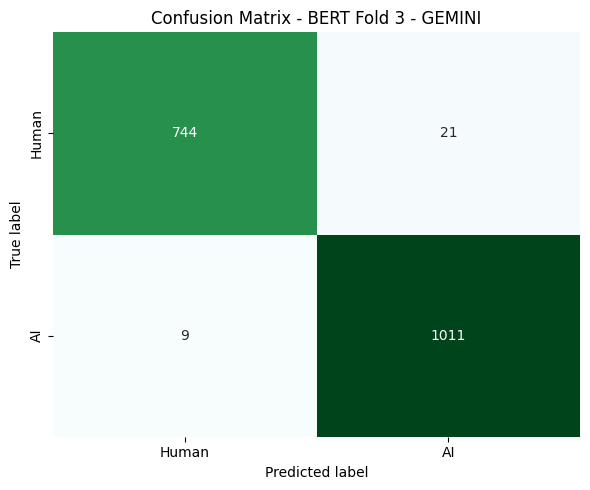

In [44]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

class_names = ["Human", "AI"]

print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

conf_mat = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    conf_mat,
    annot=True,
    fmt="d",
    cmap="BuGn",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=False
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix - BERT Fold 3 - GEMINI")
plt.tight_layout()
plt.show()

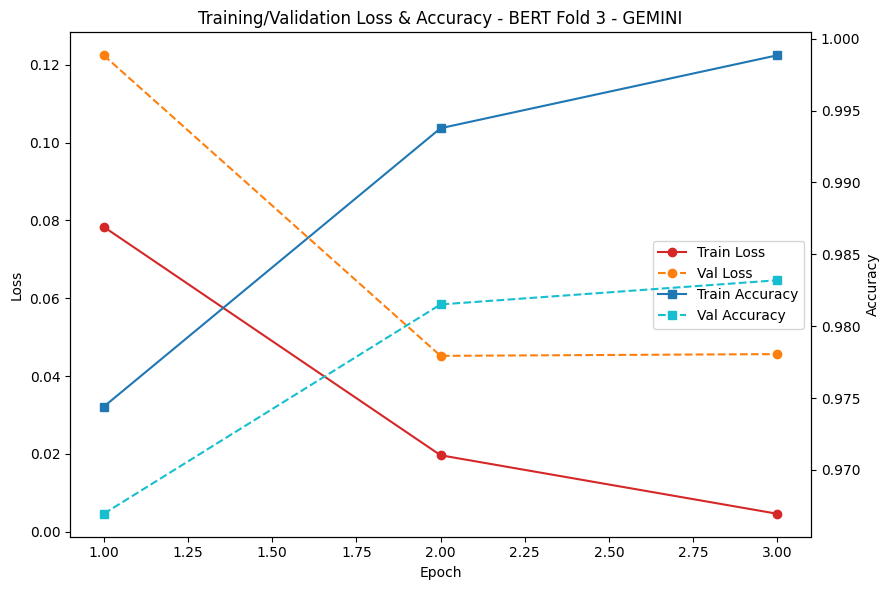

In [45]:
import matplotlib.pyplot as plt

hist = history.history
epochs_range = range(1, len(hist["loss"]) + 1)

fig, ax1 = plt.subplots(figsize=(9, 6))

#loss
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
line1 = ax1.plot(epochs_range, hist["loss"], color="tab:red", marker="o", label="Train Loss")
line2 = ax1.plot(epochs_range, hist["val_loss"], color="tab:orange", marker="o", linestyle="--", label="Val Loss")
ax1.tick_params(axis="y")

#accuracy
ax2 = ax1.twinx()
ax2.set_ylabel("Accuracy")
line3 = ax2.plot(epochs_range, hist["accuracy"], color="tab:blue", marker="s", label="Train Accuracy")
line4 = ax2.plot(epochs_range, hist["val_accuracy"], color="tab:cyan", marker="s", linestyle="--", label="Val Accuracy")
ax2.tick_params(axis="y")

#legend
lines = line1 + line2 + line3 + line4
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc="center right")

plt.title("Training/Validation Loss & Accuracy - BERT Fold 3 - GEMINI")
fig.tight_layout()
plt.show()

In [46]:
examples = {
    ("correct", 0): [],
    ("correct", 1): [],
    ("incorrect", 0): [],
    ("incorrect", 1): [],
}

max_per_group = 3

for i in range(len(y_true)):
    true_label = y_true[i]
    pred_label = y_pred[i]
    is_correct = (true_label == pred_label)
    key = ("correct" if is_correct else "incorrect", true_label)

    if len(examples[key]) < max_per_group:
        examples[key].append(val_texts[i])

    if all(len(v) >= max_per_group for v in examples.values()):
        break

class_names = {0: "Human", 1: "AI"}

for (status, label), texts in examples.items():
    print(f"\n{'='*60}")
    print(f"{status.upper()} - class: {class_names[label]} ({len(texts)} examples)")
    print('='*60)
    for j, text in enumerate(texts, 1):
        print(f"\n[{j}] {text[:300]}{'...' if len(text) > 300 else ''}")


CORRECT - class: Human (3 examples)

[1] Această lucrare își propune să prezinte o scurtă clasificare a celor mai semnificative jocuri audio din perspectiva accesibilității, a funcționalității, a tehnicilor audio și a metodelor de interacțiune cu utilizatorul. 2. Descrierea jocurilor audio 2.1 Caracteristici generale ale jocurilor audio De...

[2] avut loc și, eventual, de către o locație. Aplicațiile practice realizate pentru recunoașterea evenimentelor sunt direcționate de regulă înspre un anumit domeniu specific. Totuși, majoritatea au fost dezvoltate pentru texte din rețele sociale, în special Twitter, și folosesc metode specifice regăsir...

[3] Serviciul de mesaje scurte este, de altfel, o „tehnologie socială” cu ajutorul căreia și cei mai retrași indivizi pot aduce în discuție subiecte dificile. Un studiu realizat pe 532 de subiecți, studenți (Leung, 2007), subliniază rolurile pozitive al SMS-urilor, identificate de subiecți – înfrângerea...

CORRECT - class: AI (3 examples)

[

In [47]:
#model download

model.save_pretrained("./bert-model_Fold3GEMINI")
tokenizer.save_pretrained("./bert-model_Fold3GEMINI")

from google.colab import files
import shutil
shutil.make_archive("Fold3GEMINI-bert-model", "zip", "./bert-model_Fold3GEMINI")
files.download("Fold3GEMINI-bert-model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>